<a href="https://colab.research.google.com/github/zlwym/Mann_Zoe_LabTask/blob/main/LabTask03/LabTask03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

In [26]:
df = pd.read_csv("music_streams.csv")

In [27]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,176,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,170,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,770,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,1,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,1,1101,NaN,A24 Sounds


In [28]:
df.columns

Index(['track_id', 'title', 'artist', 'genre', 'year', 'duration',
       'duration_sec', 'tempo_bpm', 'key', 'energy', 'danceability', 'valence',
       'acousticness', 'speechiness', 'loudness_db', 'explicit',
       'streams_millions', 'monthly_listeners', 'playlist_adds', 'chart_peak',
       'label'],
      dtype='object')

In [29]:
df.describe()

,year,duration_sec,tempo_bpm,energy,danceability,valence,acousticness,speechiness,loudness_db,streams_millions,monthly_listeners,playlist_adds,chart_peak
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,398.000000
mean,2020.416667,208.478333,111.85000,0.630888,0.420776,0.490212,0.492011,0.162236,-7.632583,10.171200,547.436667,18006.349167,35.271357
std,2.572983,38.430439,24.02079,0.197475,0.185624,0.190506,0.199972,0.175026,3.440571,23.480756,1167.522745,41026.124735,42.904225
min,2015.000000,90.000000,60.00000,0.062000,0.000000,0.023000,0.000000,0.006000,-20.000000,0.050000,1.000000,50.000000,1.000000
25%,2018.000000,183.000000,89.00000,0.487000,0.291000,0.352000,0.354750,0.057000,-9.900000,1.740000,95.750000,2483.750000,9.000000
50%,2021.000000,208.000000,117.00000,0.641500,0.426000,0.498500,0.486500,0.101000,-7.600000,4.060000,223.000000,6641.500000,19.000000
75%,2023.000000,234.000000,131.00000,0.773250,0.545000,0.623250,0.630000,0.190500,-5.300000,10.330000,555.250000,17412.750000,43.000000
max,2024.000000,325.000000,165.00000,1.000000,1.000000,0.969000,1.000000,1.000000,-1.000000,523.170000,16655.000000,646358.000000,200.000000


## Histogram

**Monthly Streams Histogram**

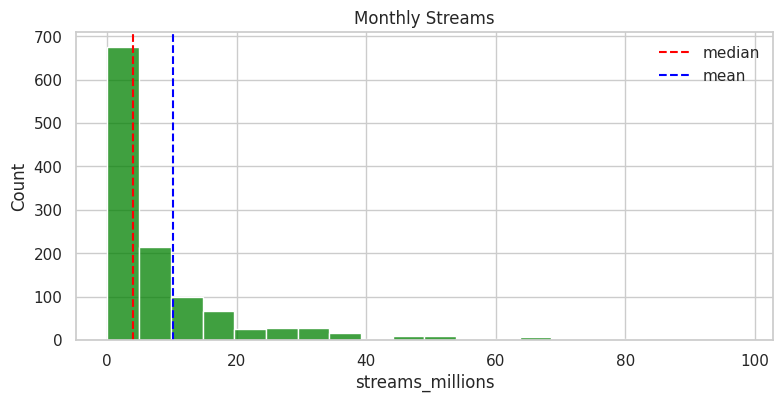

In [30]:

fig, ax = plt.subplots(figsize=(9, 4))
median = df.streams_millions.median()
mean = df.streams_millions.mean()

sns.histplot(data = df[df.streams_millions < 100], x = 'streams_millions', bins = 20, ax=ax, color = 'green')
ax.axvline(median, color = "red", linestyle = "dashed", label = "median")
ax.axvline(mean, color = "blue", linestyle = "dashed", label = "mean")
ax.legend(frameon = False)
ax.set_title("Monthly Streams")
plt.show()


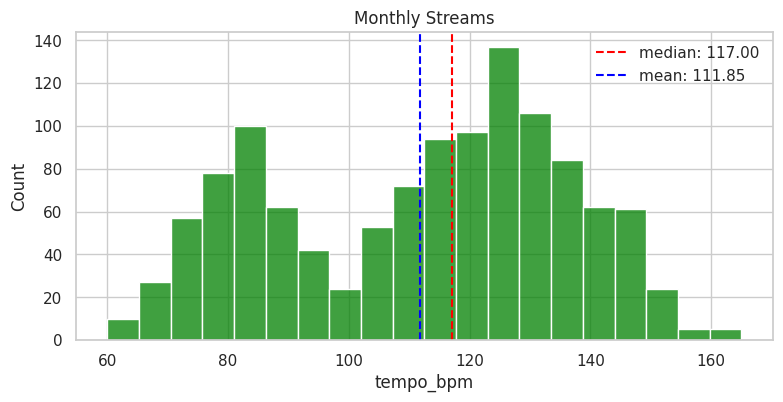

In [31]:

fig, ax = plt.subplots(figsize=(9, 4))
median = df.tempo_bpm.median()
mean = df.tempo_bpm.mean()

sns.histplot(data = df, x = 'tempo_bpm', bins = 20, ax=ax, color = 'green')
ax.axvline(median, color = "red", linestyle = "dashed", label = f"median: {median:.2f}")
ax.axvline(mean, color = "blue", linestyle = "dashed", label = f"mean: {mean:.2f}")
ax.legend(frameon = False)
ax.set_title("Monthly Streams")
plt.show()


## Boxplots

In [32]:
order = df.groupby("genre")["energy"].median().sort_values(ascending=False).index
order

Index(['Electronic', 'Rock', 'Latin', 'Hip-Hop', 'Pop', 'Country', 'Indie',
       'R&B'],
      dtype='object', name='genre')

<Axes: xlabel='genre', ylabel='energy'>

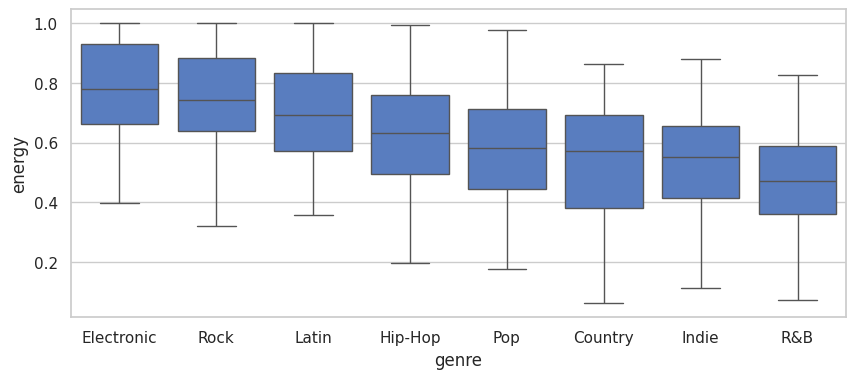

In [33]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=df, y="energy", x="genre", order=order)

In [34]:
df["label"].unique()

array(['AWAL', 'A24 Sounds', 'Dead Oceans', 'Sony Music',
       'Secretly Canadian', 'Sub Pop', 'Warner Music', 'Beggars Group',
       'Big Machine', 'Universal Music', 'Concord', 'Interscope',
       'Jagjaguwar'], dtype=object)

In [35]:
order = df.groupby("label")["loudness_db"].median().sort_values(ascending=False).index

Text(0.5, 1.0, 'Loudness by Label')

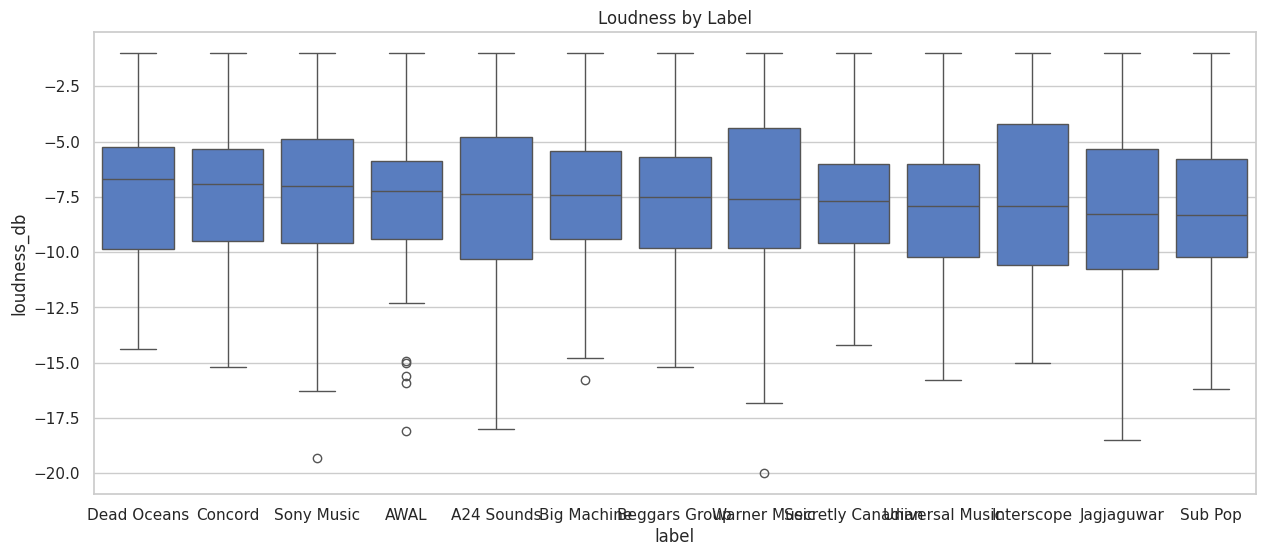

In [36]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=df, y="loudness_db", x="label", order=order)
ax.set_title("Loudness by Label")

Text(0.5, 1.0, 'Monthly Listeners by Label')

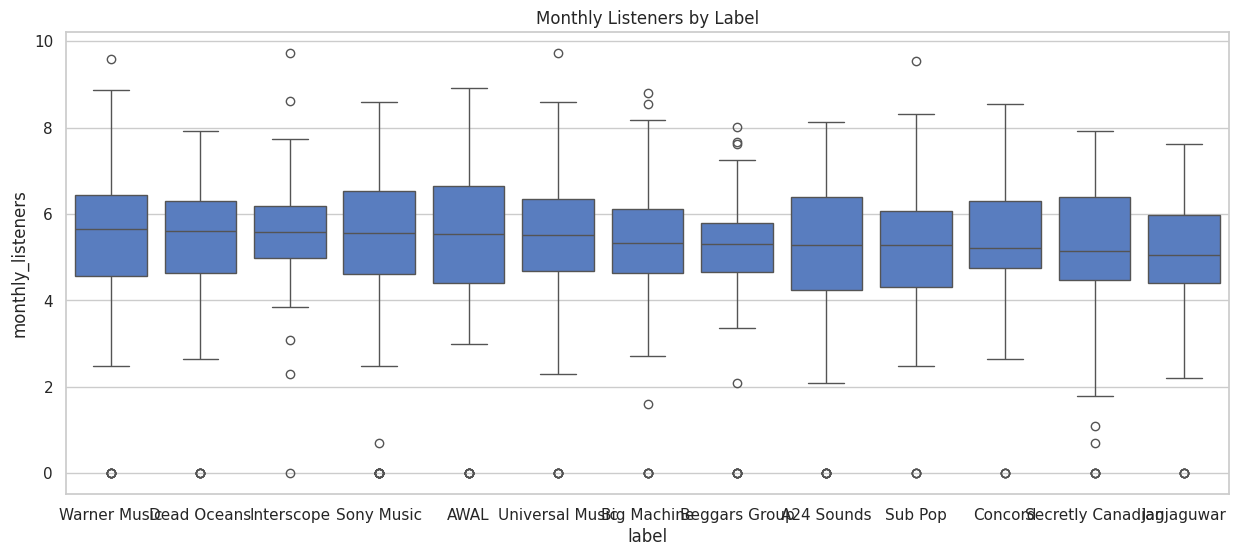

In [37]:
df["monthly_listeners"] = np.log(df["monthly_listeners"])

order = df.groupby("label")["monthly_listeners"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(15, 6))
sns.boxplot(data=df, y="monthly_listeners", x="label", order=order)
ax.set_title("Monthly Listeners by Label")

## Scatterplot

Text(0.5, 1.0, 'Energy vs Danceability')

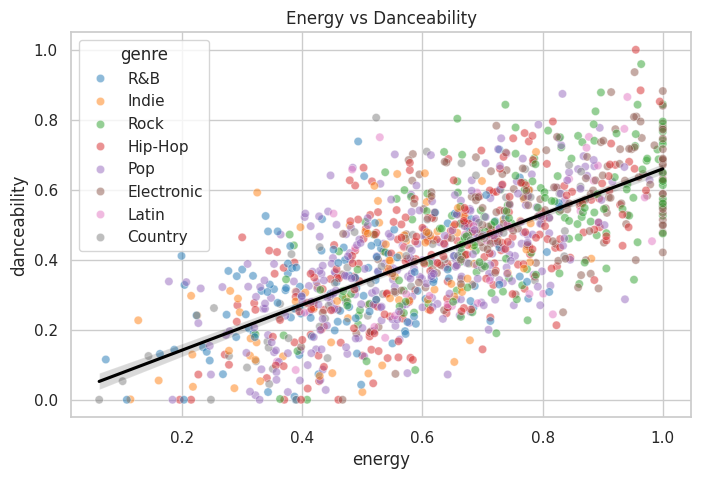

In [38]:
Sample = df.sample(600)
fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(data=df, x="energy", y="danceability", hue="genre", color="grey", alpha=0.5, palette="tab10")
sns.regplot(data=df, x='energy', y='danceability', color="black", scatter=False)

ax.set_title("Energy vs Danceability")

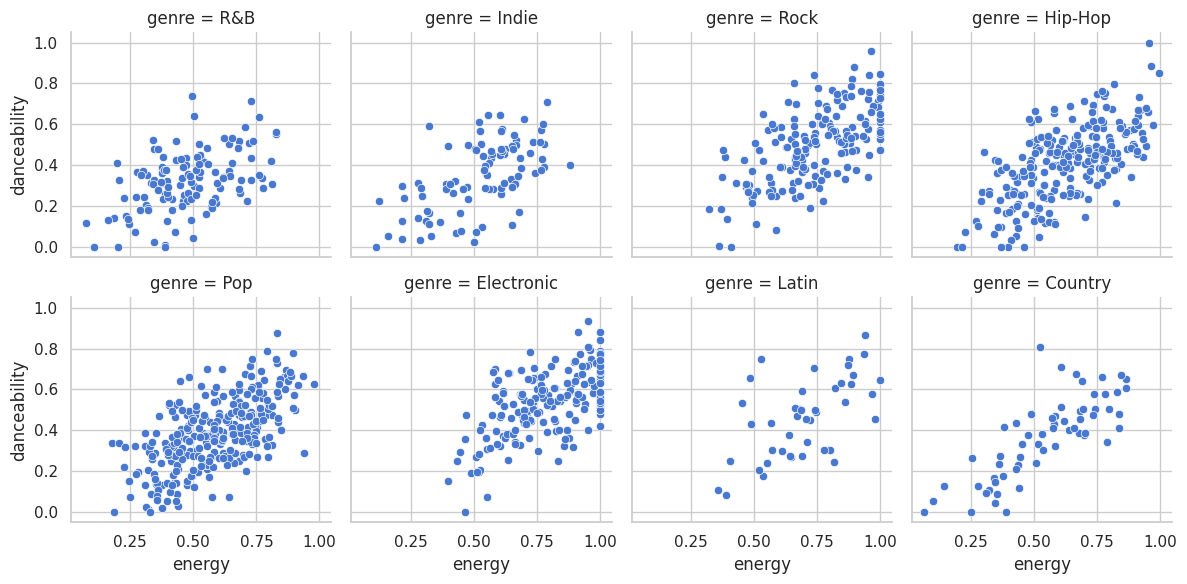

In [39]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "energy","danceability")

Text(0.5, 1.0, 'Tempo vs Acousticness')

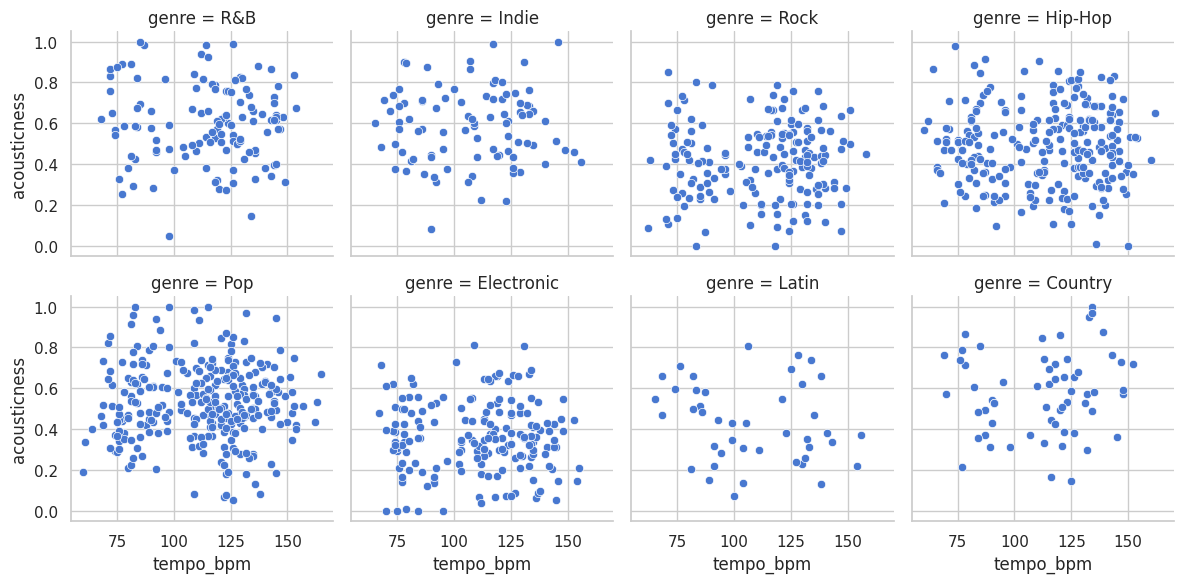

In [40]:
g = sns.FacetGrid(df, col="genre", col_wrap=4)
g.map(sns.scatterplot, "tempo_bpm","acousticness")

ax.set_title("Tempo vs Acousticness")

## Line Charts and Friends

In [41]:
df.head()

,track_id,title,artist,genre,year,duration,duration_sec,tempo_bpm,key,energy,...,valence,acousticness,speechiness,loudness_db,explicit,streams_millions,monthly_listeners,playlist_adds,chart_peak,label
0,TRK00001,Memories,Juno Calloway,R&B,2024,3:15,195,85,F Minor,0.502,...,0.872,0.694,0.148,-8.8,False,3.73,5.170484,8336,NaN,AWAL
1,TRK00002,Tears,Cleo Nova,Indie,2020,2:40,160,68,F# Major,0.610,...,0.545,0.485,0.111,-3.9,False,3.10,5.135798,1625,NaN,A24 Sounds
2,TRK00003,Soul,Cole Voss ft. Indigo Ashford,Rock,2017,3:55,235,140,D Major,0.742,...,0.483,0.281,0.050,-4.1,True,18.22,6.646391,42971,NaN,Dead Oceans
3,TRK00004,Heart,Asha Ashford,Rock,2022,3:05,185,73,A Major,0.643,...,0.634,0.505,0.092,-8.6,False,0.23,0.000000,484,NaN,Sony Music
4,TRK00005,Bones,Theo Blaine,Hip-Hop,2015,3:09,189,143,G# Major,0.770,...,0.223,0.394,0.105,-13.4,False,0.72,0.000000,1101,NaN,A24 Sounds


In [42]:
df.year.unique()

array([2024, 2020, 2017, 2022, 2015, 2023, 2021, 2019, 2018, 2016])

In [43]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["streams_millions"].median()
pop_trend

,streams_millions
year,
2015,7.160
2016,3.540
2017,3.560
2018,11.370
2019,4.720
2020,5.075
2021,3.645
2022,4.445
2023,4.230


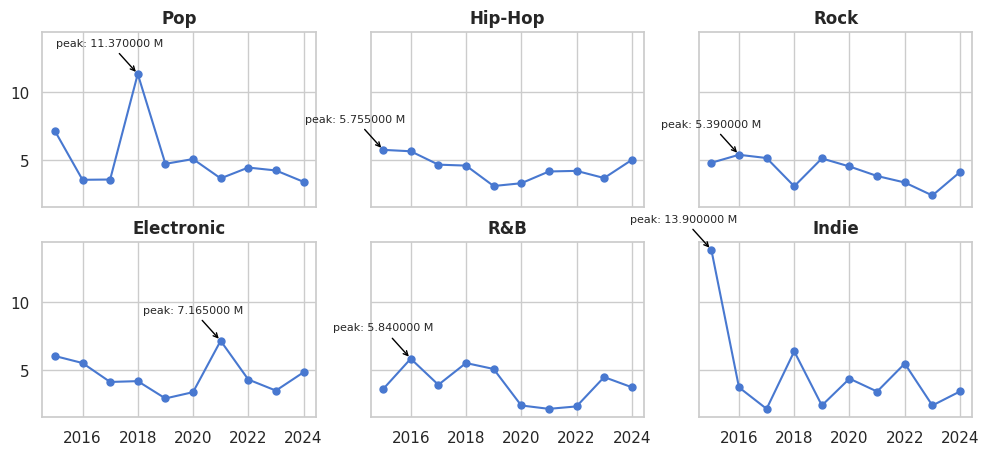

In [44]:
genres = ["Pop", "Hip-Hop", "Rock", "Electronic", "R&B", "Indie"]
trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["streams_millions"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(12, 5), sharex = True, sharey = True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
  subD = trend[trend.genre == genre]
  ax.plot(subD.year, subD.streams_millions, marker="o", ms=5)
  peak = subD.loc[subD.streams_millions.idxmax()]
  ax.annotate(f"peak: {peak.streams_millions:1f} M", xy=(peak.year, peak.streams_millions), xytext=(-20,20),
              textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", color="black", lw=1))
  ax.set_title(genre, fontweight="bold")

In [45]:
df["genre"].unique()

array(['R&B', 'Indie', 'Rock', 'Hip-Hop', 'Pop', 'Electronic', 'Latin',
       'Country'], dtype=object)

In [54]:
pop_trend = df[df["genre"] == "Pop"].groupby("year")["monthly_listeners"].median()
pop_trend

,monthly_listeners
year,
2015,5.793014
2016,5.283204
2017,5.068904
2018,6.421758
2019,5.342334
2020,5.557937
2021,5.541194
2022,5.337434
2023,5.446737


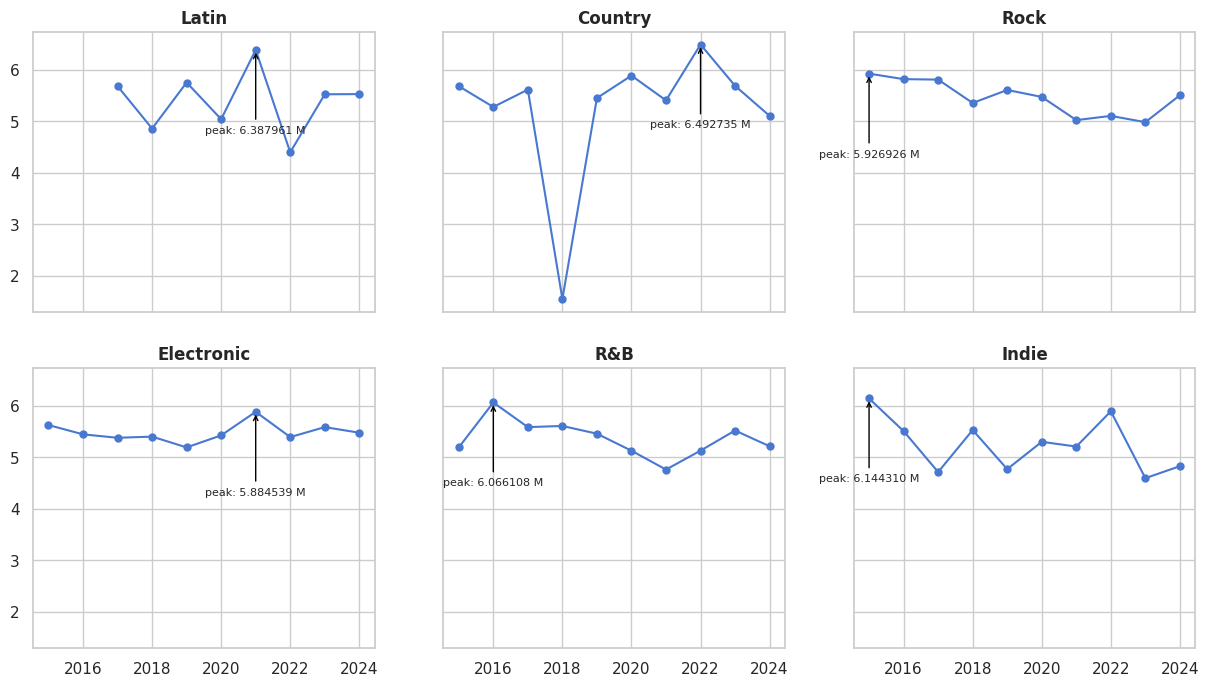

In [63]:
genres = ["Latin", "Country", "Rock", "Electronic", "R&B", "Indie"]
trend = df[df.genre.isin(genres)].groupby(["year", "genre"])["monthly_listeners"].median().reset_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex = True, sharey = True)
axes = axes.flatten()

for ax, genre in zip(axes, genres):
  subD = trend[trend.genre == genre]
  ax.plot(subD.year, subD.monthly_listeners, marker="o", ms=5)
  peak = subD.loc[subD.monthly_listeners.idxmax()]
  ax.annotate(f"peak: {peak.monthly_listeners:1f} M", xy=(peak.year, peak.monthly_listeners), xytext=(0,-60),
              textcoords="offset points", ha="center", fontsize=8, arrowprops=dict(arrowstyle="->", color="black", lw=1))
  ax.set_title(genre, fontweight="bold")